# Assignment 3 : Soli Radar Gesture Recognition via Adversarial Training

# Setup & Preprocessing

## Install & Extract Data

In [2]:
import os, zipfile, glob, h5py

zip_path = r"C:\Users\Jyotirmoy Nath\Downloads\Assignment4\SoliData.zip"
extract_path = "/content/SoliData"

# Extract all files
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_path)

# Find all .h5 files
h5_files = glob.glob(f"{extract_path}/**/*.h5", recursive=True)
print(f"Found {len(h5_files)} .h5 files")

# Inspect first file
if h5_files:
    with h5py.File(h5_files[0], 'r') as f:
        for k in f.keys():
            print(f"{k}: shape={f[k].shape}, dtype={f[k].dtype}")

Found 5500 .h5 files
ch0: shape=(68, 1024), dtype=float32
ch1: shape=(68, 1024), dtype=float32
ch2: shape=(68, 1024), dtype=float32
ch3: shape=(68, 1024), dtype=float32
label: shape=(68, 1), dtype=int32


## Convert H5 → NPY

In [3]:
import os, glob, h5py, numpy as np, shutil

DSP_DIR  = "/content/SoliData"
NPY_ROOT = "/content/soli_npy"

# Reset output folder
shutil.rmtree(NPY_ROOT, ignore_errors=True)
os.makedirs(NPY_ROOT, exist_ok=True)

h5_files = glob.glob(f"{DSP_DIR}/**/*.h5", recursive=True)
print(f"Total .h5 files: {len(h5_files)}")

count = 0
for file in h5_files:
    subject = int(os.path.basename(file).split('_')[1])

    with h5py.File(file, 'r') as f:
        # Majority label
        label = np.bincount(f['label'][:].flatten().astype(int)).argmax()

        # Stack + reshape channels
        data = np.stack([f[f'ch{i}'][:] for i in range(4)]).reshape(4, -1, 32, 32)

    if label > 10:  # skip background
        continue

    save_dir = f"{NPY_ROOT}/subject_{subject:02d}/gesture_{label:02d}"
    os.makedirs(save_dir, exist_ok=True)
    np.save(f"{save_dir}/sample_{count:04d}.npy", data)

    count += 1

print(f"Saved {count} samples")

# List subjects
subjects = sorted(int(d.split('_')[1]) for d in os.listdir(NPY_ROOT) if d.startswith("subject_"))
print("Subjects found:", subjects)


Total .h5 files: 5500
Saved 5225 samples
Subjects found: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


## Train/Test Split

In [4]:
import os

NPY_ROOT = "/content/soli_npy"

all_subjects = sorted([
    int(d.replace("subject_", ""))
    for d in os.listdir(NPY_ROOT)
    if d.startswith("subject_")
])
print(f"All subjects: {all_subjects}")

half = len(all_subjects) // 2
TRAIN_SUBJECTS = all_subjects[:half]
TEST_SUBJECTS  = all_subjects[half:]
print(f"Train subjects: {TRAIN_SUBJECTS}")
print(f"Test  subjects: {TEST_SUBJECTS}")

All subjects: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Train subjects: [0, 1, 2, 3, 4, 5, 6]
Test  subjects: [7, 8, 9, 10, 11, 12, 13, 14]


## Dataset & DataLoader

In [5]:
import os, numpy as np, torch
from torch.utils.data import Dataset, DataLoader
from scipy.ndimage import zoom

SEQ_LEN = 32

class SoliDataset(Dataset):
    def __init__(self, root, subjects):
        self.samples = []

        for s in subjects:
            for g in range(11):
                path = f"{root}/subject_{s:02d}/gesture_{g:02d}"
                if not os.path.isdir(path): continue

                self.samples += [(os.path.join(path, f), g, s)
                                 for f in os.listdir(path) if f.endswith(".npy")]

        print(f"Dataset: {len(self.samples)} samples from {subjects}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label, subject = self.samples[idx]
        x = np.load(path).astype(np.float32)   # (4, 68, 32, 32)

        x = x.mean(0)                          # → (68, 32, 32)
        x = zoom(x, (1, 16/x.shape[1], 16/x.shape[2]))  # → (68, 16, 16)

        # Fix sequence length
        x = x[:SEQ_LEN] if x.shape[0] >= SEQ_LEN else \
            np.pad(x, ((0, SEQ_LEN - x.shape[0]), (0,0), (0,0)))

        # Normalize
        x = (x - x.min()) / (x.max() - x.min() + 1e-8)

        return torch.tensor(x).unsqueeze(0), label, subject


def build_loaders(root, train_ids, test_ids, bs=32):
    train = DataLoader(SoliDataset(root, train_ids), bs, shuffle=True, drop_last=True)
    test  = DataLoader(SoliDataset(root, test_ids), bs)
    return train, test


# Test
train_loader, test_loader = build_loaders(NPY_ROOT, TRAIN_SUBJECTS, TEST_SUBJECTS)
x, y, s = next(iter(train_loader))

print("Shape:", x.shape)   # (32, 1, 32, 16, 16)
print("Labels:", y[:5].tolist())
print("Subjects:", s[:5].tolist())

Dataset: 2750 samples from [0, 1, 2, 3, 4, 5, 6]
Dataset: 2475 samples from [7, 8, 9, 10, 11, 12, 13, 14]
Shape: torch.Size([32, 1, 32, 16, 16])
Labels: [9, 3, 10, 0, 1]
Subjects: [1, 3, 4, 1, 0]


## Model Architecture

# Generator, Discriminator, GestureClassifier

In [6]:

import torch
import torch.nn as nn
import torch.nn.functional as F


# Helper 
class SpectralConv3d(nn.Module):
    def __init__(self, in_c, out_c, kernel, stride=1, padding=0):
        super().__init__()
        self.conv = nn.utils.spectral_norm(
            nn.Conv3d(in_c, out_c, kernel, stride=stride, padding=padding, bias=False)
        )
    def forward(self, x): return self.conv(x)


# Generator
class Generator(nn.Module):
    def __init__(self, latent_dim=64, n_classes=11,
                 seq_len=32, range_bins=16, doppler_bins=16):
        super().__init__()
        self.latent_dim  = latent_dim
        self.seq_len     = seq_len
        self.range_bins  = range_bins
        self.doppler_bins = doppler_bins

        self.label_emb = nn.Embedding(n_classes, latent_dim)

        # Start shape: (128, 4, 2, 2)
        self.t0, self.h0, self.w0 = 4, 2, 2
        self.proj = nn.Linear(2 * latent_dim, 128 * self.t0 * self.h0 * self.w0)

        self.net = nn.Sequential(
            # (128, 4, 2, 2) → (64, 8, 4, 4)
            nn.Upsample(scale_factor=2, mode='trilinear', align_corners=False),
            SpectralConv3d(128, 64, 3, padding=1),
            nn.GroupNorm(8, 64), nn.ReLU(True),
            # → (32, 16, 8, 8)
            nn.Upsample(scale_factor=2, mode='trilinear', align_corners=False),
            SpectralConv3d(64, 32, 3, padding=1),
            nn.GroupNorm(8, 32), nn.ReLU(True),
            # → (16, 32, 16, 16)
            nn.Upsample(scale_factor=2, mode='trilinear', align_corners=False),
            SpectralConv3d(32, 16, 3, padding=1),
            nn.GroupNorm(8, 16), nn.ReLU(True),
            # → (1, 32, 16, 16)
            nn.Conv3d(16, 1, 3, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, z, labels):
        h = torch.cat([z, self.label_emb(labels)], dim=1)
        h = self.proj(h).view(h.size(0), 128, self.t0, self.h0, self.w0)
        h = self.net(h)
        # Resize to exact target dimensions
        return F.interpolate(h, size=(self.seq_len, self.range_bins, self.doppler_bins),
                             mode='trilinear', align_corners=False)

    def sample_z(self, n, device):
        return torch.randn(n, self.latent_dim, device=device)


# Discriminator (AC-GAN) 
class Discriminator(nn.Module):
    def __init__(self, n_classes=11):
        super().__init__()
        self.encoder = nn.Sequential(
            SpectralConv3d(1, 16, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, True),
            SpectralConv3d(16, 32, 4, stride=2, padding=1),
            nn.GroupNorm(8, 32), nn.LeakyReLU(0.2, True),
            SpectralConv3d(32, 64, 4, stride=2, padding=1),
            nn.GroupNorm(8, 64), nn.LeakyReLU(0.2, True),
        )
        self.pool = nn.AdaptiveAvgPool3d(1)
        self.validity_head = nn.Linear(64, 1)
        self.class_head    = nn.Linear(64, n_classes)

    def forward(self, x):
        feat = self.pool(self.encoder(x)).flatten(1)
        return self.validity_head(feat), self.class_head(feat)


# Gradient Reversal
class GradientReversalFn(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lam):
        ctx.lam = lam
        return x.clone()
    @staticmethod
    def backward(ctx, grad):
        return grad.neg() * ctx.lam, None


In [7]:
# Gesture Classifier (CNN + BiLSTM + GRL)
class GestureClassifier(nn.Module):
    def __init__(self, n_classes=11, n_subjects=10, grl_lambda=1.0):
        super().__init__()
        self.grl_lambda = grl_lambda

        # Spatial CNN: keeps time dimension, shrinks H and W
        self.cnn = nn.Sequential(
            nn.Conv3d(1, 16, kernel_size=(1,3,3), padding=(0,1,1), bias=False),
            nn.GroupNorm(8, 16), nn.ReLU(True),
            nn.Conv3d(16, 32, kernel_size=(1,3,3), stride=(1,2,2), padding=(0,1,1), bias=False),
            nn.GroupNorm(8, 32), nn.ReLU(True),
            nn.Conv3d(32, 64, kernel_size=(1,3,3), stride=(1,2,2), padding=(0,1,1), bias=False),
            nn.GroupNorm(8, 64), nn.ReLU(True),
        )
        self.spatial_pool = nn.AdaptiveAvgPool3d((None, 1, 1))  # keeps T

        # BiLSTM over time
        self.lstm = nn.LSTM(64, 64, num_layers=1, batch_first=True, bidirectional=True)

        # Gesture head
        self.gesture_head = nn.Sequential(
            nn.LayerNorm(128), nn.Dropout(0.3),
            nn.Linear(128, n_classes)
        )

        # Subject head (domain adversarial via GRL)
        self.subject_head = nn.Sequential(
            nn.LayerNorm(128), nn.Dropout(0.3),
            nn.Linear(128, n_subjects)
        )

    def set_grl_lambda(self, lam):
        self.grl_lambda = lam

    def encode(self, x):
        h = self.cnn(x)                                   # (B, 64, T, h, w)
        h = self.spatial_pool(h).squeeze(-1).squeeze(-1)  # (B, 64, T)
        h = h.permute(0, 2, 1)                            # (B, T, 64)
        out, _ = self.lstm(h)                             # (B, T, 128)
        return out.mean(dim=1)                            # (B, 128)

    def forward(self, x):
        feat = self.encode(x)
        gesture_logits = self.gesture_head(feat)
        feat_rev       = GradientReversalFn.apply(feat, self.grl_lambda)
        subject_logits = self.subject_head(feat_rev)
        return gesture_logits, subject_logits

    @torch.no_grad()
    def predict(self, x):
        return F.softmax(self.gesture_head(self.encode(x)), dim=-1)



##  Loss Functions

In [8]:

import torch, torch.nn.functional as F

def hinge_D(real_v, fake_v):
    """Discriminator hinge loss"""
    return F.relu(1.0 - real_v).mean() + F.relu(1.0 + fake_v).mean()

def hinge_G(fake_v):
    """Generator hinge loss"""
    return -fake_v.mean()

def cls_loss(logits, labels):
    """Simple cross-entropy"""
    return F.cross_entropy(logits, labels)

def domain_loss(subject_logits, subject_ids):
    """Cross-entropy on subject prediction (reversed by GRL)"""
    return F.cross_entropy(subject_logits, subject_ids)


# Training Function

In [9]:
# TRAINING FUNCTION
import torch, torch.nn as nn, torch.optim as optim
import numpy as np, os

SAVE_DIR    = "/content/results"
os.makedirs(SAVE_DIR, exist_ok=True)
device      = 'cuda' if torch.cuda.is_available() else 'cpu'
FG_CLASSES  = [0, 1, 2, 3]
HARD        = [0, 2, 3]
half        = len(all_subjects) // 2
FOLDS       = [
    {'train': all_subjects[:half], 'test': all_subjects[half:]},
    {'train': all_subjects[half:], 'test': all_subjects[:half]},
]
print(f"Device : {device}")
print(f"Fold 0 : Train={FOLDS[0]['train']}  Test={FOLDS[0]['test']}")
print(f"Fold 1 : Train={FOLDS[1]['train']}  Test={FOLDS[1]['test']}")


def run_fold(fold_idx, use_gan=True, use_grl=True,
             class_weights=None, epochs=20, tag="model"):
    """
    Trains one fold. Returns dict with acc, fg_acc, per_class, history.
    use_gan  : whether to train AC-GAN and augment classifier
    use_grl  : whether to use GRL for domain adaptation
    class_weights : tensor of shape (11,) for weighted CE loss
    """
    tr_subj = FOLDS[fold_idx]['train']
    te_subj = FOLDS[fold_idx]['test']
    tr_loader, te_loader = build_loaders(NPY_ROOT, tr_subj, te_subj, 32)

    n_sub = len(all_subjects)
    C = GestureClassifier(n_classes=11, n_subjects=n_sub).to(device)
    C.set_grl_lambda(0.0)
    opt_C  = optim.Adam(C.parameters(), lr=3e-4, weight_decay=1e-4)
    sched_C = optim.lr_scheduler.CosineAnnealingLR(opt_C, T_max=epochs, eta_min=1e-5)

    cw = class_weights.to(device) if class_weights is not None else None

    if use_gan:
        G = Generator(latent_dim=64).to(device)
        D = Discriminator(n_classes=11).to(device)
        opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5,0.999))
        opt_D = optim.Adam(D.parameters(), lr=1e-4, betas=(0.5,0.999))
        buf_x, buf_y = [], []

        def add_buf(x, y):
            buf_x.extend(x.detach().cpu())
            buf_y.extend(y.detach().cpu())
            while len(buf_x) > 500: buf_x.pop(0); buf_y.pop(0)

        def sample_buf(n):
            if len(buf_x) < n: return None, None
            idx = np.random.choice(len(buf_x), n, replace=False)
            return (torch.stack([buf_x[i] for i in idx]).to(device),
                    torch.stack([buf_y[i] for i in idx]).long().to(device))

    best_acc = 0.0
    history  = []
    best_preds = best_trues = None

    for epoch in range(1, epochs + 1):
        C.train()
        lam = 0.5 / (1.0 + np.exp(-10.0 * (epoch/epochs - 0.5))) if use_grl else 0.0
        C.set_grl_lambda(lam)
        c_ls = []

        for rx, ry, rs in tr_loader:
            B  = rx.size(0)
            rx = rx.to(device)
            ry = ry.long().to(device)
            rs = torch.tensor([all_subjects.index(int(s)) for s in rs],
                               dtype=torch.long, device=device)

            if use_gan:
                G.train(); D.train()
                # Train D
                opt_D.zero_grad()
                fl  = torch.tensor(np.random.choice(HARD, B),
                                   dtype=torch.long, device=device)
                fx  = G(G.sample_z(B, device), fl).detach()
                rv2, rc2 = D(rx); fv, fc = D(fx)
                dl = (nn.functional.relu(1-rv2).mean() +
                      nn.functional.relu(1+fv).mean()  +
                      nn.functional.cross_entropy(rc2, ry) +
                      nn.functional.cross_entropy(fc, fl))
                dl.backward(); opt_D.step()

                # Train G
                opt_G.zero_grad()
                fl2 = torch.tensor(np.random.choice(HARD, B),
                                   dtype=torch.long, device=device)
                fv2, fc2 = D(G(G.sample_z(B, device), fl2))
                gl = -fv2.mean() + nn.functional.cross_entropy(fc2, fl2)
                gl.backward(); opt_G.step()

                # Fill buffer
                with torch.no_grad():
                    y3 = torch.tensor(np.random.choice(HARD, 16),
                                      dtype=torch.long, device=device)
                    add_buf(G(G.sample_z(16, device), y3), y3)

            # Train Classifier
            opt_C.zero_grad()
            mx, my, ms = rx, ry, rs
            if use_gan and epoch > 5:
                sx, sy = sample_buf(B // 3)
                if sx is not None:
                    ds = torch.full((sx.size(0),), n_sub-1,
                                    dtype=torch.long, device=device)
                    mx = torch.cat([rx, sx])
                    my = torch.cat([ry, sy])
                    ms = torch.cat([rs, ds])

            g_logits, s_logits = C(mx)
            c_loss = nn.functional.cross_entropy(g_logits, my, weight=cw)
            if use_grl:
                c_loss = c_loss + 0.3 * nn.functional.cross_entropy(s_logits, ms)
            c_loss.backward()
            nn.utils.clip_grad_norm_(C.parameters(), 1.0)
            opt_C.step()
            c_ls.append(c_loss.item())

        sched_C.step()

        # Evaluate
        C.eval()
        preds, trues = [], []
        with torch.no_grad():
            for x, y, _ in te_loader:
                preds.extend(C.predict(x.to(device)).argmax(1).cpu().numpy())
                trues.extend(np.array(y))
        preds, trues = np.array(preds), np.array(trues)
        acc     = float((preds == trues).mean())
        fg_mask = np.isin(trues, FG_CLASSES)
        fg_acc  = float((preds[fg_mask]==trues[fg_mask]).mean()) if fg_mask.sum()>0 else 0.0

        if acc > best_acc:
            best_acc   = acc
            best_preds = preds.copy()
            best_trues = trues.copy()

        history.append({'epoch': epoch, 'cls': float(np.mean(c_ls)),
                        'acc': acc, 'fg_acc': fg_acc})
        print(f"  [{epoch:03d}/{epochs}] CLS={np.mean(c_ls):.3f}  "
              f"Acc={acc:.3f}  FG={fg_acc:.3f}  λ={lam:.2f}"
              + (f"  Buf={len(buf_x)}" if use_gan else ""))

    per_class = {c: float((best_preds[best_trues==c]==c).mean())
                 if (best_trues==c).sum()>0 else 0.0 for c in range(11)}
    fg_acc_best = float(np.mean([per_class[c] for c in FG_CLASSES]))

    print(f"\n  [{tag} Fold {fold_idx}] Best Acc={best_acc:.4f}  FG={fg_acc_best:.4f}")

        # Save model checkpoint
    save_path = f"{SAVE_DIR}/{tag}_fold{fold_idx}_best.pt"
    torch.save({
        'classifier': C.state_dict(),
        'generator':  G.state_dict() if use_gan else None,
        'best_acc':   best_acc,
        'fg_acc':     fg_acc_best,
        'fold':       fold_idx,
        'tag':        tag,
    }, save_path)
    print(f"  Model saved → {save_path}")

    return {'fold': fold_idx, 'tag': tag, 'best_acc': best_acc,
            'fg_acc': fg_acc_best, 'per_class': per_class,
            'history': history, 'preds': best_preds, 'trues': best_trues}



Device : cpu
Fold 0 : Train=[0, 1, 2, 3, 4, 5, 6]  Test=[7, 8, 9, 10, 11, 12, 13, 14]
Fold 1 : Train=[7, 8, 9, 10, 11, 12, 13, 14]  Test=[0, 1, 2, 3, 4, 5, 6]


# Baseline (No GAN, No GRL)

In [10]:
# BASELINE (No GAN, No GRL), 2 Folds

print("  BASELINE — Fold 0")
base_f0 = run_fold(0, use_gan=False, use_grl=False,
                   class_weights=None, tag="baseline")

print("  BASELINE — Fold 1")
base_f1 = run_fold(1, use_gan=False, use_grl=False,
                   class_weights=None, tag="baseline")

BASE_AVG_ACC = (base_f0['best_acc'] + base_f1['best_acc']) / 2
BASE_AVG_FG  = (base_f0['fg_acc']   + base_f1['fg_acc'])   / 2
BASE_AVG_PC  = {c: (base_f0['per_class'][c] + base_f1['per_class'][c]) / 2
                for c in range(11)}

print(f"\nBaseline 2-Fold , Overall={BASE_AVG_ACC:.4f}  FG={BASE_AVG_FG:.4f}")



  BASELINE — Fold 0
Dataset: 2750 samples from [0, 1, 2, 3, 4, 5, 6]
Dataset: 2475 samples from [7, 8, 9, 10, 11, 12, 13, 14]


C:\Users\Jyotirmoy Nath\AppData\Local\Temp\ipykernel_7092\2064656744.py:132: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  trues.extend(np.array(y))


  [001/20] CLS=2.105  Acc=0.459  FG=0.537  λ=0.00
  [002/20] CLS=1.308  Acc=0.593  FG=0.614  λ=0.00
  [003/20] CLS=0.895  Acc=0.640  FG=0.550  λ=0.00
  [004/20] CLS=0.710  Acc=0.663  FG=0.629  λ=0.00
  [005/20] CLS=0.598  Acc=0.685  FG=0.591  λ=0.00
  [006/20] CLS=0.517  Acc=0.678  FG=0.614  λ=0.00
  [007/20] CLS=0.460  Acc=0.726  FG=0.623  λ=0.00
  [008/20] CLS=0.412  Acc=0.718  FG=0.576  λ=0.00
  [009/20] CLS=0.386  Acc=0.746  FG=0.598  λ=0.00
  [010/20] CLS=0.360  Acc=0.705  FG=0.678  λ=0.00
  [011/20] CLS=0.326  Acc=0.769  FG=0.647  λ=0.00
  [012/20] CLS=0.302  Acc=0.756  FG=0.658  λ=0.00
  [013/20] CLS=0.290  Acc=0.720  FG=0.634  λ=0.00
  [014/20] CLS=0.267  Acc=0.714  FG=0.662  λ=0.00
  [015/20] CLS=0.255  Acc=0.758  FG=0.674  λ=0.00
  [016/20] CLS=0.241  Acc=0.739  FG=0.688  λ=0.00
  [017/20] CLS=0.224  Acc=0.749  FG=0.684  λ=0.00
  [018/20] CLS=0.213  Acc=0.751  FG=0.663  λ=0.00
  [019/20] CLS=0.218  Acc=0.747  FG=0.682  λ=0.00
  [020/20] CLS=0.203  Acc=0.762  FG=0.671  λ=0.00


# Part 1: Fine-Grained Improvement (AC-GAN + Weighted Loss)

In [11]:
#  (GAN + FG Weighted Loss, GRL OFF) — 2 Folds

cw_part1 = torch.ones(11)
cw_part1[0] = 3.5   # finger_slider
cw_part1[1] = 1.2   # finger_rub (already high)
cw_part1[2] = 3.5   # pinch_index
cw_part1[3] = 3.0   # pinch_pinky

print("=" * 55)
print("  PART 1 — Fold 0")
p1_f0 = run_fold(0, use_gan=True, use_grl=False,
                 class_weights=cw_part1, tag="part1")

print("\n" + "=" * 55)
print("  PART 1 — Fold 1")
p1_f1 = run_fold(1, use_gan=True, use_grl=False,
                 class_weights=cw_part1, tag="part1")

P1_AVG_ACC = (p1_f0['best_acc'] + p1_f1['best_acc']) / 2
P1_AVG_FG  = (p1_f0['fg_acc']   + p1_f1['fg_acc'])   / 2
P1_AVG_PC  = {c: (p1_f0['per_class'][c] + p1_f1['per_class'][c]) / 2
              for c in range(11)}

print(f"\nPart 1 2-Fold → Overall={P1_AVG_ACC:.4f}  FG={P1_AVG_FG:.4f}")


  PART 1 — Fold 0
Dataset: 2750 samples from [0, 1, 2, 3, 4, 5, 6]
Dataset: 2475 samples from [7, 8, 9, 10, 11, 12, 13, 14]


C:\Users\Jyotirmoy Nath\AppData\Local\Temp\ipykernel_7092\2064656744.py:132: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  trues.extend(np.array(y))


  [001/20] CLS=2.141  Acc=0.321  FG=0.567  λ=0.00  Buf=500
  [002/20] CLS=1.448  Acc=0.528  FG=0.693  λ=0.00  Buf=500
  [003/20] CLS=1.037  Acc=0.575  FG=0.666  λ=0.00  Buf=500
  [004/20] CLS=0.837  Acc=0.598  FG=0.643  λ=0.00  Buf=500
  [005/20] CLS=0.745  Acc=0.656  FG=0.678  λ=0.00  Buf=500
  [006/20] CLS=0.896  Acc=0.529  FG=0.698  λ=0.00  Buf=500
  [007/20] CLS=0.759  Acc=0.601  FG=0.607  λ=0.00  Buf=500
  [008/20] CLS=0.545  Acc=0.589  FG=0.574  λ=0.00  Buf=500
  [009/20] CLS=0.537  Acc=0.629  FG=0.657  λ=0.00  Buf=500
  [010/20] CLS=0.497  Acc=0.639  FG=0.644  λ=0.00  Buf=500
  [011/20] CLS=0.439  Acc=0.648  FG=0.666  λ=0.00  Buf=500
  [012/20] CLS=0.410  Acc=0.648  FG=0.618  λ=0.00  Buf=500
  [013/20] CLS=0.538  Acc=0.660  FG=0.660  λ=0.00  Buf=500
  [014/20] CLS=0.488  Acc=0.660  FG=0.637  λ=0.00  Buf=500
  [015/20] CLS=0.476  Acc=0.650  FG=0.631  λ=0.00  Buf=500
  [016/20] CLS=0.388  Acc=0.669  FG=0.647  λ=0.00  Buf=500
  [017/20] CLS=0.456  Acc=0.667  FG=0.677  λ=0.00  Buf=5

# Part 2: Cross-Subject Generalization (Full Model: GAN + GRL + FG)

In [12]:
# PART 2 FULL MODEL (GAN + GRL + FG Boost), 2 Folds

cw_part2 = torch.ones(11)
cw_part2[0] = 3.5
cw_part2[1] = 1.2
cw_part2[2] = 3.5
cw_part2[3] = 3.0

print("  PART 2 FULL MODEL — Fold 0")
p2_f0 = run_fold(0, use_gan=True, use_grl=True,
                 class_weights=cw_part2, tag="full")

print("  PART 2 FULL MODEL — Fold 1")
p2_f1 = run_fold(1, use_gan=True, use_grl=True,
                 class_weights=cw_part2, tag="full")

P2_AVG_ACC = (p2_f0['best_acc'] + p2_f1['best_acc']) / 2
P2_AVG_FG  = (p2_f0['fg_acc']   + p2_f1['fg_acc'])   / 2
P2_AVG_PC  = {c: (p2_f0['per_class'][c] + p2_f1['per_class'][c]) / 2
              for c in range(11)}

print(f"\nFull Model 2-Fold , Overall={P2_AVG_ACC:.4f}  FG={P2_AVG_FG:.4f}")


  PART 2 FULL MODEL — Fold 0
Dataset: 2750 samples from [0, 1, 2, 3, 4, 5, 6]
Dataset: 2475 samples from [7, 8, 9, 10, 11, 12, 13, 14]


C:\Users\Jyotirmoy Nath\AppData\Local\Temp\ipykernel_7092\2064656744.py:132: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  trues.extend(np.array(y))


  [001/20] CLS=2.756  Acc=0.343  FG=0.639  λ=0.01  Buf=500
  [002/20] CLS=2.006  Acc=0.532  FG=0.666  λ=0.01  Buf=500
  [003/20] CLS=1.690  Acc=0.590  FG=0.600  λ=0.01  Buf=500
  [004/20] CLS=1.506  Acc=0.616  FG=0.583  λ=0.02  Buf=500
  [005/20] CLS=1.415  Acc=0.644  FG=0.708  λ=0.04  Buf=500
  [006/20] CLS=1.620  Acc=0.590  FG=0.699  λ=0.06  Buf=500
  [007/20] CLS=1.249  Acc=0.598  FG=0.606  λ=0.09  Buf=500
  [008/20] CLS=1.177  Acc=0.655  FG=0.712  λ=0.13  Buf=500
  [009/20] CLS=1.258  Acc=0.661  FG=0.702  λ=0.19  Buf=500
  [010/20] CLS=1.325  Acc=0.677  FG=0.681  λ=0.25  Buf=500
  [011/20] CLS=1.290  Acc=0.656  FG=0.677  λ=0.31  Buf=500
  [012/20] CLS=1.239  Acc=0.653  FG=0.581  λ=0.37  Buf=500
  [013/20] CLS=1.215  Acc=0.630  FG=0.648  λ=0.41  Buf=500
  [014/20] CLS=1.232  Acc=0.655  FG=0.688  λ=0.44  Buf=500
  [015/20] CLS=1.135  Acc=0.687  FG=0.663  λ=0.46  Buf=500
  [016/20] CLS=1.177  Acc=0.644  FG=0.663  λ=0.48  Buf=500
  [017/20] CLS=1.172  Acc=0.684  FG=0.693  λ=0.49  Buf=5

In [13]:
# FINAL 2-FOLD RESULTS TABLE

fg_names = {0:"finger_slider", 1:"finger_rub",
            2:"pinch_index",   3:"pinch_pinky"}

print("  ABLATION STUDY — 2-Fold Cross-Validation Averages")
print(f"{'Model':<25} {'Overall Acc':>12} {'FG Acc':>10} {'Improvement':>12}")
print("-"*68)
rows = [
    ("Baseline",              BASE_AVG_ACC, BASE_AVG_FG),
    ("Part1 (GAN+FGBoost)",   P1_AVG_ACC,  P1_AVG_FG),
    ("Part2 (GAN+GRL+FG)",    P2_AVG_ACC,  P2_AVG_FG),
]
for name, oa, fg in rows:
    diff_oa = oa - BASE_AVG_ACC
    print(f"  {name:<23} {oa:>12.4f} {fg:>10.4f} {diff_oa:>+12.4f}")
print("="*68)

print("\nFine-Grained Per-Class (2-Fold Average):")
print(f"{'Gesture':<18} {'Baseline':>10} {'Part1':>8} {'Part2':>8} {'Δ (Part2-Base)':>16}")
print("-"*60)
for c in FG_CLASSES:
    b = BASE_AVG_PC[c]; p1 = P1_AVG_PC[c]; p2 = P2_AVG_PC[c]
    print(f"  {fg_names[c]:<16} {b:>10.3f} {p1:>8.3f} {p2:>8.3f} {p2-b:>+16.3f}")


  ABLATION STUDY — 2-Fold Cross-Validation Averages
Model                      Overall Acc     FG Acc  Improvement
--------------------------------------------------------------------
  Baseline                      0.7670     0.6753      +0.0000
  Part1 (GAN+FGBoost)           0.6938     0.6958      -0.0732
  Part2 (GAN+GRL+FG)            0.6913     0.6762      -0.0757

Fine-Grained Per-Class (2-Fold Average):
Gesture              Baseline    Part1    Part2   Δ (Part2-Base)
------------------------------------------------------------
  finger_slider         0.558    0.683    0.644           +0.086
  finger_rub            0.954    0.920    0.920           -0.034
  pinch_index           0.578    0.612    0.486           -0.092
  pinch_pinky           0.612    0.569    0.655           +0.043


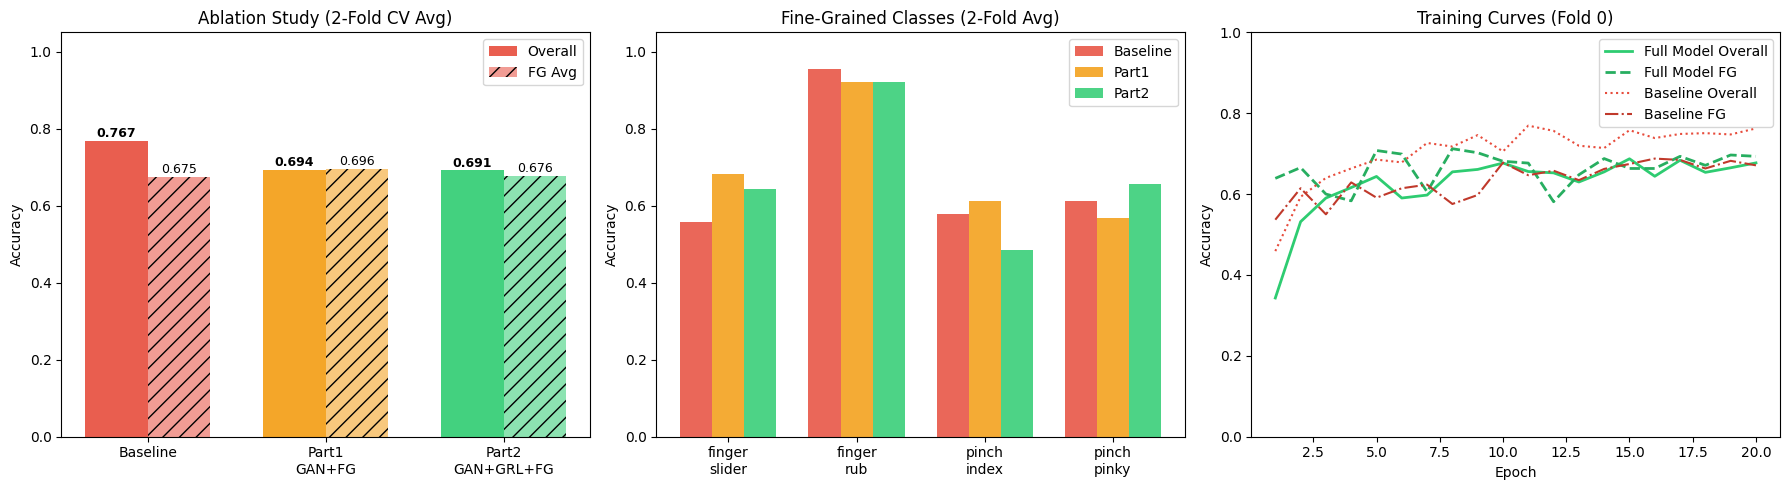

Saved: final_results_2fold.png


In [14]:
#  PLOTS BASED ON 2-FOLD AVERAGES
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Plot 1: Overall vs FG Accuracy (all 3 models) ────────────────
models  = ['Baseline', 'Part1\nGAN+FG', 'Part2\nGAN+GRL+FG']
ov_accs = [BASE_AVG_ACC, P1_AVG_ACC, P2_AVG_ACC]
fg_accs = [BASE_AVG_FG,  P1_AVG_FG,  P2_AVG_FG]
colors  = ['#e74c3c', '#f39c12', '#2ecc71']
x = np.arange(3); w = 0.35
axes[0].bar(x-w/2, ov_accs, w, label='Overall', color=colors, alpha=0.9)
axes[0].bar(x+w/2, fg_accs, w, label='FG Avg',  color=colors, alpha=0.55, hatch='//')
for i, (o, f) in enumerate(zip(ov_accs, fg_accs)):
    axes[0].text(i-w/2, o+0.01, f'{o:.3f}', ha='center', fontsize=9, fontweight='bold')
    axes[0].text(i+w/2, f+0.01, f'{f:.3f}', ha='center', fontsize=9)
axes[0].set_xticks(x); axes[0].set_xticklabels(models)
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Ablation Study (2-Fold CV Avg)'); axes[0].legend()

# ── Plot 2: FG Per-Class All Models ──────────────────────────────
x2  = np.arange(4); w2 = 0.25
b_v = [BASE_AVG_PC[c] for c in FG_CLASSES]
p1_v= [P1_AVG_PC[c]   for c in FG_CLASSES]
p2_v= [P2_AVG_PC[c]   for c in FG_CLASSES]
axes[1].bar(x2-w2, b_v,  w2, label='Baseline', color='#e74c3c', alpha=0.85)
axes[1].bar(x2,    p1_v, w2, label='Part1',    color='#f39c12', alpha=0.85)
axes[1].bar(x2+w2, p2_v, w2, label='Part2',    color='#2ecc71', alpha=0.85)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(['finger\nslider','finger\nrub',
                          'pinch\nindex','pinch\npinky'])
axes[1].set_ylim(0, 1.05); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Fine-Grained Classes (2-Fold Avg)'); axes[1].legend()

# ── Plot 3: Training Curves (Fold 0, Full Model vs Baseline) ─────
ep  = [r['epoch']   for r in p2_f0['history']]
ep_b= [r['epoch']   for r in base_f0['history']]
axes[2].plot(ep,  [r['acc']    for r in p2_f0['history']],
             label='Full Model Overall', lw=2, color='#2ecc71')
axes[2].plot(ep,  [r['fg_acc'] for r in p2_f0['history']],
             label='Full Model FG', lw=2, ls='--', color='#27ae60')
axes[2].plot(ep_b,[r['acc']    for r in base_f0['history']],
             label='Baseline Overall', lw=1.5, ls=':', color='#e74c3c')
axes[2].plot(ep_b,[r['fg_acc'] for r in base_f0['history']],
             label='Baseline FG', lw=1.5, ls='-.', color='#c0392b')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Accuracy')
axes[2].set_title('Training Curves (Fold 0)'); axes[2].legend()
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/final_results_2fold.png", dpi=150)
plt.show()
print("Saved: final_results_2fold.png")


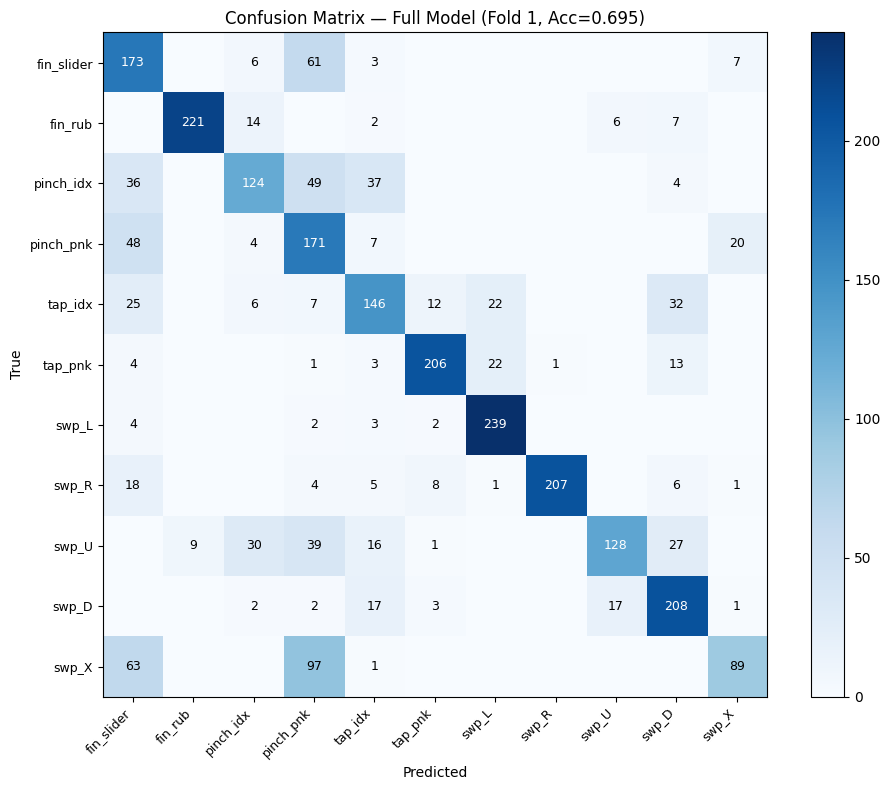

Saved: confusion_matrix.png


In [15]:
# CONFUSION MATRIX

# Use whichever fold had better accuracy
best_fold_res = p2_f0 if p2_f0['best_acc'] >= p2_f1['best_acc'] else p2_f1
preds_cm = best_fold_res['preds']
trues_cm = best_fold_res['trues']

n = 11
cm = np.zeros((n, n), dtype=int)
for p, l in zip(preds_cm, trues_cm):
    cm[l, p] += 1

label_names = ['fin_slider','fin_rub','pinch_idx','pinch_pnk',
               'tap_idx','tap_pnk','swp_L','swp_R','swp_U','swp_D','swp_X']

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(label_names, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(label_names, fontsize=9)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix — Full Model '
             f'(Fold {best_fold_res["fold"]}, Acc={best_fold_res["best_acc"]:.3f})')
for i in range(n):
    for j in range(n):
        if cm[i, j] > 0:
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=9,
                    color='white' if cm[i,j] > cm.max()*0.5 else 'black')
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/confusion_matrix.png", dpi=150)
plt.show()
print("Saved: confusion_matrix.png")
